# Gamma Sweep — Hybrid Facet Re-ranking

Sweeps the facet re-ranking weight **γ** over `[0.1, 0.3, 0.5, 0.7, 0.9]`.

The hybrid retriever fuses dense + facet cosine per trait:

$$\text{score} = (1-\gamma)\cdot\cos_{\text{dense}} + \gamma\cdot\cos_{\text{facet}}$$

For each γ we run the **full end-to-end pipeline** on the **50-row subset** (`test50.csv`):
1. Build a `HybridFacetRetriever` with uniform trait weights `(β=1-γ, γ)`.
2. Run `predict()` on the 50-essay subset (real GPT-4o-mini calls).
3. `evaluate()` → per-trait **classification report** (accuracy, macro/weighted F1).
4. Compute **RAG metrics** (MMR@k, HR@k) on the same retrieval.
5. Save everything under `result/gamma_sweep/gamma_{value}/`.

After all γ finish, a final section aggregates the sweep into combined CSVs + plots.

> ⏱️ On 50 essays each γ runs ~50–60 min of API calls (≈5× faster than the full
> 247-row test set). The notebook **skips** any γ whose result folder already has
> `evaluation_summary.csv`, so it is resumable — just re-run after an interruption.

## Configuration

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
for _ in range(4):
    if (project_root / "ptd_model").exists():
        break
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# ── gamma sweep grid ───────────────────────────────────────────────────────────
GAMMAS = [0.1, 0.3, 0.5, 0.7, 0.9]

# ── prediction settings ──────────────────────────────────────────────────────────
# NOTE: "reasoned_rag_def_oneshot_30f" is the only prompt_mode the current
# ptd_model/predict.py supports — it is the one that builds the RAG retriever and
# passes query_profile_dict (so the gamma hybrid re-rank actually fires).
model_name     = "gpt-4o-mini"
prompt_mode    = "reasoned_rag_def_oneshot_30f"
max_new_tokens = 512
temperature    = 0.0
top_k          = 5

# ── RAG metric k values ────────────────────────────────────────────────
K_VALUES = [5]   # k=5 only, for a faster sweep

# ── paths ────────────────────────────────────────────────────────────
# Sweep runs on the 50-row subset (test50.csv). Profiles are reused from the
# full essays_test store (test50 is the first 50 rows of test.csv), so we load
# both: full_test_csv supplies the profile<->text linkage, test50 drives the run.
test_csv        = str(project_root / "data/split/essays/test50.csv")
full_test_csv   = str(project_root / "data/split/essays/test.csv")
test_profile_db = str(project_root / "data/profile_db/essays_test")
profiler_model  = "gpt-4o-mini"

res_dir         = str(project_root / "result")
log_dir         = str(project_root / "log")
sweep_root      = project_root / "result" / "gamma_sweep"

# hybrid_facet always uses the dual index (+ facet_vectors.npy)
vector_db_dir = str(project_root / "data/vector_db/essays_dual")

TRAITS = {
    "cOPN": "Openness to Experience",
    "cCON": "Conscientiousness",
    "cEXT": "Extraversion",
    "cAGR": "Agreeableness",
    "cNEU": "Neuroticism",
}
TRAIT_NAMES = list(TRAITS.values())
TRAIT_CODES = {v: k for k, v in TRAITS.items()}
TRAIT_SHORT = {
    "cOPN": "Openness",
    "cCON": "Conscientiousness",
    "cEXT": "Extraversion",
    "cAGR": "Agreeableness",
    "cNEU": "Neuroticism",
}

def gamma_dir(g: float) -> Path:
    """Result folder for one gamma, e.g. result/gamma_sweep/gamma_0.5."""
    return sweep_root / f"gamma_{g}"

print(f"Project root : {project_root}")
print(f"gammas       : {GAMMAS}")
print(f"test set     : {test_csv}  (50-row subset)")
print(f"prompt_mode  : {prompt_mode}  |  top_k={top_k}")
print(f"k values     : {K_VALUES}")
print(f"index dir    : {vector_db_dir}")
print(f"sweep root   : {sweep_root}")

Project root : F:\std\GR\code\model_x_ocean
gammas       : [0.1, 0.3, 0.5, 0.7, 0.9]
test set     : F:\std\GR\code\model_x_ocean\data\split\essays\test50.csv  (50-row subset)
prompt_mode  : reasoned_rag_def_oneshot_30f  |  top_k=5
k values     : [5]
index dir    : F:\std\GR\code\model_x_ocean\data\vector_db\essays_dual
sweep root   : F:\std\GR\code\model_x_ocean\result\gamma_sweep


## Imports & path checks

In [2]:
import os, json, time
from typing import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rag.embedder         import get_dual_embedding
from rag.profiler.store   import ProfileStore
from rag.profiler.runner  import build_profiles
from rag.profiler.prompts import FACETS
from rag.facet_vector     import facet_vector, FACET_ORDER
import rag.retriever as _retriever_mod
from rag.retriever import FeatureRAGRetriever

from ptd_model.predict   import predict
from ptd_model.evaluate  import evaluate

def normalize_label(val):
    s = str(val).strip().lower()
    if s in ("1", "1.0"): return "high"
    if s in ("0", "0.0"): return "low"
    return s

# ── load data ──────────────────────────────────────────────────────────
# test_df    -> the 50-row subset the sweep actually runs on
# full_test_df -> full 247-row split, used only to map text -> existing profile
test_df      = pd.read_csv(test_csv)
full_test_df = pd.read_csv(full_test_csv)
print(f"Test subset (test50): {len(test_df)} rows")
print(f"Full test split     : {len(full_test_df)} rows")

# every test50 text must exist in the full split (so its profile is available)
missing = (~test_df["text"].isin(set(full_test_df["text"]))).sum()
print(f"test50 texts missing from full split: {missing}  (must be 0)")

for label, p in [("test_csv", test_csv), ("test_profile_db", test_profile_db), ("index_dir", vector_db_dir)]:
    ok = Path(p).exists()
    print(f"  {'OK' if ok else 'MISSING':7s}  {label}: {p}")

fp = Path(vector_db_dir) / "facet_vectors.npy"
print(f"  {'OK' if fp.exists() else 'MISSING':7s}  facet_vectors.npy  (required for hybrid re-rank)")

Test subset (test50): 50 rows
Full test split     : 247 rows
test50 texts missing from full split: 0  (must be 0)
  OK       test_csv: F:\std\GR\code\model_x_ocean\data\split\essays\test50.csv
  OK       test_profile_db: F:\std\GR\code\model_x_ocean\data\profile_db\essays_test
  OK       index_dir: F:\std\GR\code\model_x_ocean\data\vector_db\essays_dual
  OK       facet_vectors.npy  (required for hybrid re-rank)


## Step 1 — Profile the test set (label-blind)

Test profiles are generated **without labels** to avoid leakage. We profile the
**full** test split and key profiles by essay text, so every `test50` row resolves
to its precomputed profile (no re-profiling). Skipped entirely if the
`essays_test` store is already complete.

In [3]:
test_store_path = Path(test_profile_db) / "profile_store.jsonl"
test_store = ProfileStore(str(test_store_path))
test_store.load()
needed = len(full_test_df) - sum(
    1 for i in range(len(full_test_df))
    if test_store.has(f"user_{i}") and test_store.get(f"user_{i}").get("valid")
)
print(f"Profiles in store: {len(test_store)}; missing (vs full split): {needed}")

if needed > 0:
    test_store = build_profiles(
        data       = full_test_df,
        output_dir = test_profile_db,
        model_name = profiler_model,
        log_dir    = str(Path(log_dir) / "profiler_test"),
        use_labels = False,
    )

# map essay text -> profile entry, via the full split's row order (store keys)
_full_texts = full_test_df["text"].tolist()
test_profiles_by_text = {}
for e in test_store.get_all():
    if not e.get("valid"):
        continue
    ridx = int(e["user_id"].split("_")[1])
    if 0 <= ridx < len(_full_texts):
        test_profiles_by_text[str(_full_texts[ridx])] = e

# how many of the 50 subset rows have a profile?
have = sum(1 for t in test_df["text"] if str(t) in test_profiles_by_text)
print(f"Profiles available for test50: {have} / {len(test_df)}")

Profiles in store: 247; missing (vs full split): 0
Profiles available for test50: 50 / 50


## Step 2 — Gamma-parametrised hybrid retriever

`HybridFacetRetriever` is the proposed pipeline: a dual-fused query (raw + full
profile) plus per-trait facet cosine re-ranking. The only thing the sweep changes
is the fusion weight: we set **uniform** trait weights `(β=1−γ, γ)` so γ is the single
swept variable across all five traits.

`predict()` constructs its retriever via `rag.retriever.FeatureRAGRetriever(db_dir=...)`,
so we monkey-patch that symbol with a factory bound to the current γ. `set_gamma(g)`
rebinds the factory before each run.

In [4]:
ALPHA = 0.5  # raw-vs-profile fusion weight (matches build_dual_index.ipynb)

def _profile_to_full_text(entry: Dict) -> str:
    facets = entry.get("facets", {})
    ling   = entry.get("linguistic", {})
    lines  = ["[FACETS]"]
    for code, name, *_ in FACETS:
        f = facets.get(code, {})
        lines.append(f"{code} {name:<18}| {f.get('signal','')} | {f.get('evidence','')}")
    lines.append("\n[LINGUISTIC]")
    for k, v in ling.items():
        lines.append(f"{k}: {v}")
    return "\n".join(lines)


class GammaHybridRetriever(FeatureRAGRetriever):
    """Dual-fused query + per-trait facet cosine re-rank with a fixed gamma.

    Trait weights are uniform: every trait uses (beta=1-gamma, gamma), so gamma
    is the single knob being swept. Profiles are looked up by essay text.
    """
    def __init__(self, db_dir, gamma, profiles_by_text):
        weights = {name: (1.0 - gamma, gamma) for name in TRAIT_NAMES}
        super().__init__(db_dir=db_dir, use_hybrid=True, trait_weights=weights)
        self._gamma            = gamma
        self._profiles_by_text = profiles_by_text

    def _lookup_profile(self, text):
        return self._profiles_by_text.get(str(text))

    # dual-fused query embedding (raw + full profile)
    def _embed_query(self, text, profile_text=None):
        entry = self._lookup_profile(text)
        if entry and entry.get("valid"):
            return get_dual_embedding(str(text), _profile_to_full_text(entry), alpha=ALPHA)
        return super()._embed_query(str(text))

    def metric_retrieve(self, posts, trait, top_k=5):
        """retrieve() for the RAG-metric loop, passing the precomputed test profile
        dict so the hybrid (gamma) re-rank path actually fires."""
        entry = self._lookup_profile(posts)
        return self.retrieve(
            posts=str(posts),
            trait=trait,
            top_k=top_k,
            query_profile_dict=entry if (entry and entry.get("valid")) else None,
        )


_OriginalRetriever = _retriever_mod.FeatureRAGRetriever
_current_gamma = {"value": None}

def make_retriever(gamma, db_dir=None):
    return GammaHybridRetriever(
        db_dir           = db_dir or vector_db_dir,
        gamma            = gamma,
        profiles_by_text = test_profiles_by_text,
    )

def set_gamma(gamma):
    """Bind predict()'s FeatureRAGRetriever to a gamma-parametrised factory."""
    _current_gamma["value"] = gamma
    def _factory(db_dir=None):
        return make_retriever(gamma, db_dir=db_dir)
    _retriever_mod.FeatureRAGRetriever = _factory
    print(f"[adapter] hybrid retriever installed  (gamma={gamma}, beta={1-gamma:.1f})")

print("GammaHybridRetriever ready.")

GammaHybridRetriever ready.


## Step 3 — Sanity check

Confirms the gamma re-rank path fires (results carry per-candidate `scores`:
`fused` / `dense` / `facet`) and returns labelled neighbours.

In [5]:
_smoke      = make_retriever(gamma=0.5)
_query_text = test_df.iloc[0]["text"]

for trait_full in TRAIT_NAMES[:2]:
    results = _smoke.metric_retrieve(posts=_query_text, trait=trait_full, top_k=top_k)
    print(f"\n=== {trait_full} ({len(results)} retrieved) ===")
    for i, r in enumerate(results):
        sc = r.get("scores", {})
        print(f"  [{i+1}] label={r.get('label','?')}  "
              f"fused={sc.get('fused',0):.3f} dense={sc.get('dense',0):.3f} facet={sc.get('facet',0):.3f}")

[retriever] mode='legacy'  dir='F:\\std\\GR\\code\\model_x_ocean\\data\\vector_db\\essays_dual'  hybrid=True
[embedder] Loading embedding model: nomic-ai/nomic-embed-text-v1.5


<All keys matched successfully>


[retriever] Legacy index loaded (1974 vectors).
[retriever] Facet matrix loaded ((1974, 30)).

=== Openness to Experience (5 retrieved) ===
  [1] label=high  fused=0.896 dense=1.000 facet=0.792
  [2] label=high  fused=0.820 dense=0.848 facet=0.792
  [3] label=high  fused=0.659 dense=0.397 facet=0.920
  [4] label=high  fused=0.651 dense=0.510 facet=0.792
  [5] label=low  fused=0.369 dense=0.738 facet=0.000

=== Conscientiousness (5 retrieved) ===
  [1] label=high  fused=0.853 dense=0.738 facet=0.969
  [2] label=high  fused=0.620 dense=0.272 facet=0.969
  [3] label=high  fused=0.583 dense=1.000 facet=0.167
  [4] label=low  fused=0.516 dense=0.360 facet=0.671
  [5] label=high  fused=0.507 dense=0.848 facet=0.167


## Step 4 — Per-gamma helpers (predict → evaluate → RAG metrics)

`run_one_gamma(g)` runs the full pipeline for a single γ and writes everything to
`result/gamma_sweep/gamma_{g}/`:

| file | content |
|---|---|
| `predictions.csv` | raw per-essay predictions |
| `evaluation_summary.csv` | accuracy + macro/weighted F1 per trait |
| `{Trait}_classification_report.txt` | full sklearn classification report |
| `rag_summary.csv` | MMR@k / HR@k per trait |
| `rag_per_query.csv` | per-query retrieval matches |
| `meta.json` | gamma, beta, run_id, timing |

It **skips** γ whose folder already has `evaluation_summary.csv` (resumable).

In [6]:
def compute_rag_metrics(retriever, gamma):
    """MMR@k / HR@k per trait using the gamma hybrid retriever (no API calls)."""
    rag_rows, per_query_rows = [], []
    for k in K_VALUES:
        for tc, trait_full in TRAITS.items():
            match_rates, hits = [], []
            for qi, (_, row) in enumerate(test_df.iterrows()):
                gt = normalize_label(row[tc])
                if gt not in ("high", "low"):
                    continue
                retrieved = retriever.metric_retrieve(posts=str(row["text"]), trait=trait_full, top_k=k)
                n_ret   = len(retrieved)
                matches = sum(
                    1 for r in retrieved
                    if (r.get("label") or r.get("trait_labels", {}).get(trait_full)) == gt
                )
                rate = matches / n_ret if n_ret > 0 else 0.0
                match_rates.append(rate)
                hits.append(int(matches > 0))
                per_query_rows.append({
                    "gamma": gamma, "query_idx": qi, "trait": trait_full, "k": k,
                    "true_label": gt, "n_retrieved": n_ret, "match_count": matches,
                    "match_rate": rate, "hit": int(matches > 0),
                })
            rag_rows.append({
                "gamma": gamma, "trait": trait_full, "k": k,
                "n_queries": len(match_rates),
                "mean_match_rate": round(float(np.mean(match_rates)), 4),
                "std_match_rate":  round(float(np.std(match_rates)), 4),
                "hit_rate":        round(float(np.mean(hits)), 4),
            })
    return pd.DataFrame(rag_rows), pd.DataFrame(per_query_rows)


def run_one_gamma(gamma, force=False):
    out_dir = gamma_dir(gamma)
    out_dir.mkdir(parents=True, exist_ok=True)
    summary_path = out_dir / "evaluation_summary.csv"

    if summary_path.exists() and not force:
        print(f"⏭️  gamma={gamma}: already done ({summary_path}). Skipping."
              "  Pass force=True to re-run.")
        return

    print(f"\n{'='*72}\n  GAMMA = {gamma}   (beta={1-gamma:.1f})\n{'='*72}")
    set_gamma(gamma)

    # ── 1. predict (uses the patched gamma retriever) ─────────────────────────
    t0 = time.time()
    run_id, run_time, prediction_csv = predict(
        text_df        = test_df,
        model_name     = model_name,
        log_dir        = log_dir,
        prompt_mode    = prompt_mode,
        max_new_tokens = max_new_tokens,
        res_dir        = res_dir,
        temperature    = temperature,
        top_k          = top_k,
        vector_db_dir  = vector_db_dir,
    )
    print(f"[gamma={gamma}] predict done in {run_time:.1f}s -> {prediction_csv}")

    # ── 2. evaluate -> classification report (acc / macro-F1 / weighted-F1) ──────
    evaluation = evaluate(
        prediction_csv = prediction_csv,
        model_name     = model_name,
        res_dir        = res_dir,
        run_time       = run_time,
        prompt_mode    = prompt_mode,
        run_id         = run_id,
        vector_db_dir  = vector_db_dir,
    )
    eval_df = pd.read_csv(evaluation["summary_csv"])
    eval_df.insert(0, "gamma", gamma)

    # ── 3. RAG metrics on the same gamma retrieval ───────────────────────────
    metric_retriever = make_retriever(gamma=gamma)
    rag_summary_df, per_query_df = compute_rag_metrics(metric_retriever, gamma)

    # ── 4. persist to result/gamma_sweep/gamma_{g}/ ──────────────────────────
    eval_df.to_csv(out_dir / "evaluation_summary.csv", index=False)
    rag_summary_df.to_csv(out_dir / "rag_summary.csv", index=False)
    per_query_df.to_csv(out_dir / "rag_per_query.csv", index=False)
    # copy the per-trait classification report .txt files into the gamma folder
    for trait, src in evaluation["report_paths"].items():
        dst = out_dir / f"{trait}_classification_report.txt"
        dst.write_text(Path(src).read_text(encoding="utf-8"), encoding="utf-8")
    # copy the predictions predict() already wrote (text + true + pred_ columns)
    pd.read_csv(prediction_csv).to_csv(out_dir / "predictions.csv", index=False)
    (out_dir / "meta.json").write_text(json.dumps({
        "gamma": gamma, "beta": round(1 - gamma, 4),
        "model_name": model_name, "prompt_mode": prompt_mode,
        "top_k": top_k, "k_values": K_VALUES,
        "run_id": run_id, "predict_seconds": round(run_time, 1),
        "total_seconds": round(time.time() - t0, 1),
        "source_prediction_csv": prediction_csv,
    }, indent=2), encoding="utf-8")

    print(f"\n[gamma={gamma}] saved to {out_dir}")
    print("\n  --- classification (per trait) ---")
    print(eval_df[["trait", "accuracy", "macro_f1", "weighted_f1"]].to_string(index=False))
    print("\n  --- RAG metrics ---")
    print(rag_summary_df[["trait", "k", "mean_match_rate", "hit_rate"]].to_string(index=False))
    return eval_df, rag_summary_df

## Step 5 — Run the sweep

Iterates all γ on the 50-row subset (~50–60 min each). Resumable: re-running skips
any γ that already has `evaluation_summary.csv`. To force a re-run of a single γ use
`run_one_gamma(0.5, force=True)`.

In [7]:
for g in GAMMAS:
    run_one_gamma(g)

# restore the original retriever so later cells / other notebooks are unaffected
_retriever_mod.FeatureRAGRetriever = _OriginalRetriever
print("\n[adapter] Original FeatureRAGRetriever restored. Sweep complete.")


  GAMMA = 0.1   (beta=0.9)
[adapter] hybrid retriever installed  (gamma=0.1, beta=0.9)
[retriever] mode='legacy'  dir='F:\\std\\GR\\code\\model_x_ocean\\data\\vector_db\\essays_dual'  hybrid=True
[predict] RAG retriever ready (top_k=5).
[predict] 50 records | mode=reasoned_rag_def_oneshot_30f | model=gpt-4o-mini
[retriever] Legacy index loaded (1974 vectors).
[retriever] Facet matrix loaded ((1974, 30)).
  [predict] 10/50 done.
  [predict] 20/50 done.
  [predict] 30/50 done.
  [predict] 40/50 done.
  [predict] 50/50 done.
[predict] Finished in 2785.06s -> F:\std\GR\code\model_x_ocean\result\gpt-4o-mini\reasoned_rag_def_oneshot_30f\20260614-110121\predictions.csv
[gamma=0.1] predict done in 2785.1s -> F:\std\GR\code\model_x_ocean\result\gpt-4o-mini\reasoned_rag_def_oneshot_30f\20260614-110121\predictions.csv
Loaded predictions from F:\std\GR\code\model_x_ocean\result\gpt-4o-mini\reasoned_rag_def_oneshot_30f\20260614-110121\predictions.csv
Saved evaluation summary to F:\std\GR\code\mode

## Step 6 — Aggregate the sweep

Loads every `gamma_{g}/` folder, concatenates the classification + RAG metrics,
and writes combined CSVs to `result/gamma_sweep/`.

In [8]:
sweep_root.mkdir(parents=True, exist_ok=True)

eval_frames, rag_frames = [], []
for g in GAMMAS:
    d = gamma_dir(g)
    if (d / "evaluation_summary.csv").exists():
        eval_frames.append(pd.read_csv(d / "evaluation_summary.csv"))
    if (d / "rag_summary.csv").exists():
        rag_frames.append(pd.read_csv(d / "rag_summary.csv"))

all_eval = pd.concat(eval_frames, ignore_index=True) if eval_frames else pd.DataFrame()
all_rag  = pd.concat(rag_frames,  ignore_index=True) if rag_frames  else pd.DataFrame()

if all_eval.empty and all_rag.empty:
    print("No per-gamma results found under", sweep_root)
    print("Run Step 5 first (at least one gamma must finish).")
else:
    all_eval.to_csv(sweep_root / "all_gamma_classification.csv", index=False)
    all_rag.to_csv(sweep_root / "all_gamma_rag.csv", index=False)
    print(f"Wrote {sweep_root/'all_gamma_classification.csv'}  ({len(all_eval)} rows)")
    print(f"Wrote {sweep_root/'all_gamma_rag.csv'}  ({len(all_rag)} rows)")

    if not all_eval.empty:
        print("\n=== mean macro-F1 / accuracy per gamma (avg over traits) ===")
        summary = (all_eval.groupby("gamma")[["accuracy", "macro_f1", "weighted_f1"]]
                   .mean().round(4))
        display(summary)

    if not all_rag.empty:
        print("\n=== mean MMR / HR per gamma (avg over traits) ===")
        for k in K_VALUES:
            sub = (all_rag[all_rag["k"] == k].groupby("gamma")[["mean_match_rate", "hit_rate"]]
                   .mean().round(4))
            print(f"\nk={k}")
            display(sub)

Wrote F:\std\GR\code\model_x_ocean\result\gamma_sweep\all_gamma_classification.csv  (25 rows)
Wrote F:\std\GR\code\model_x_ocean\result\gamma_sweep\all_gamma_rag.csv  (25 rows)

=== mean macro-F1 / accuracy per gamma (avg over traits) ===


,accuracy,macro_f1,weighted_f1
gamma,,,
0.1,0.612,0.5769,0.5850
0.3,0.596,0.5630,0.5722
0.5,0.576,0.5321,0.5407
0.7,0.572,0.5330,0.5437
0.9,0.600,0.5687,0.5777



=== mean MMR / HR per gamma (avg over traits) ===

k=5


,mean_match_rate,hit_rate
gamma,,
0.1,0.5176,0.956
0.3,0.5232,0.948
0.5,0.5288,0.876
0.7,0.5360,0.828
0.9,0.5384,0.780


## Step 7 — Sweep plots

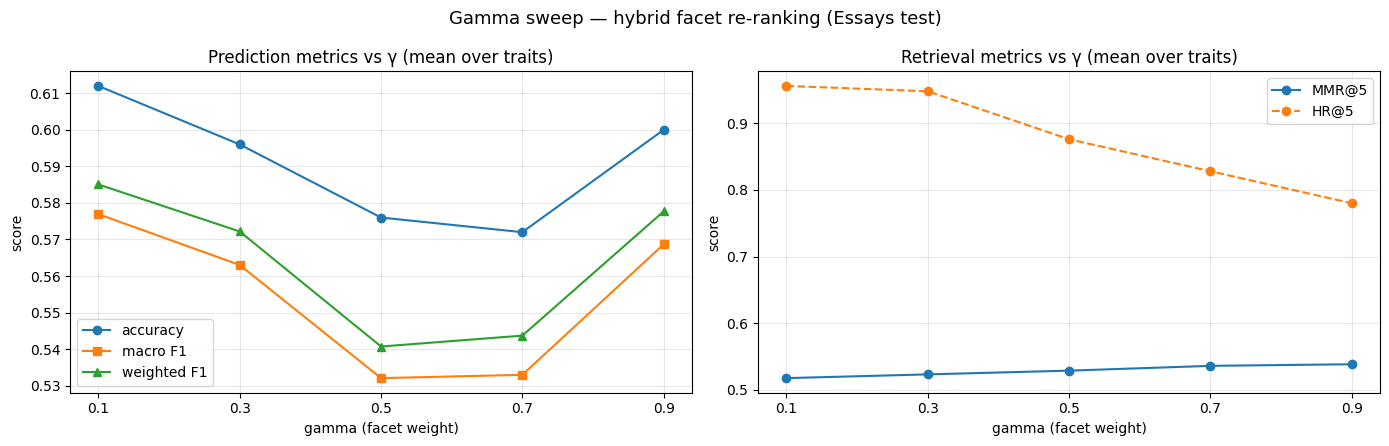

Saved: F:\std\GR\code\model_x_ocean\result\gamma_sweep\gamma_sweep.png


In [9]:
if not all_eval.empty and not all_rag.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # (a) classification metrics vs gamma
    cls = all_eval.groupby("gamma")[["accuracy", "macro_f1", "weighted_f1"]].mean()
    ax = axes[0]
    ax.plot(cls.index, cls["accuracy"],    "o-", label="accuracy")
    ax.plot(cls.index, cls["macro_f1"],    "s-", label="macro F1")
    ax.plot(cls.index, cls["weighted_f1"], "^-", label="weighted F1")
    ax.set_xlabel("gamma (facet weight)"); ax.set_ylabel("score")
    ax.set_title("Prediction metrics vs γ (mean over traits)")
    ax.set_xticks(GAMMAS); ax.grid(alpha=0.3); ax.legend()

    # (b) RAG metrics vs gamma
    ax = axes[1]
    for k, marker in zip(K_VALUES, ["o", "s"]):
        sub = all_rag[all_rag["k"] == k].groupby("gamma")[["mean_match_rate", "hit_rate"]].mean()
        ax.plot(sub.index, sub["mean_match_rate"], marker+"-", label=f"MMR@{k}")
        ax.plot(sub.index, sub["hit_rate"],        marker+"--", label=f"HR@{k}")
    ax.set_xlabel("gamma (facet weight)"); ax.set_ylabel("score")
    ax.set_title("Retrieval metrics vs γ (mean over traits)")
    ax.set_xticks(GAMMAS); ax.grid(alpha=0.3); ax.legend()

    plt.suptitle("Gamma sweep — hybrid facet re-ranking (Essays test)", fontsize=13)
    plt.tight_layout()
    plot_path = sweep_root / "gamma_sweep.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {plot_path}")
else:
    print("No results yet — run Step 5 first.")

## Step 8 — F1 score vs γ (per trait)

A line graph of the **macro-F1** score against the facet re-ranking weight **γ**,
with one line per Big-Five trait plus a bold dashed line for the mean over traits.

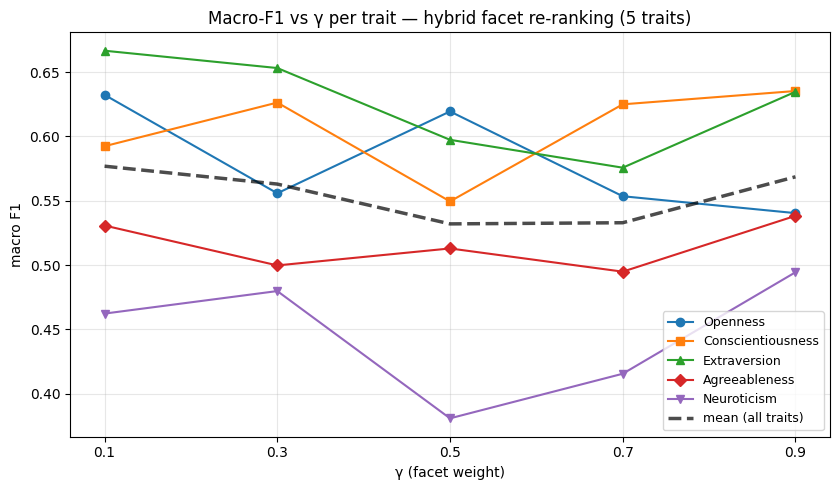

Saved: F:\std\GR\code\model_x_ocean\result\gamma_sweep\gamma_f1_per_trait.png

=== macro-F1 per trait per gamma (5 traits) ===


trait,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism
gamma,,,,,
0.1,0.6324,0.5924,0.6667,0.5308,0.4624
0.3,0.5559,0.6264,0.6532,0.4998,0.4799
0.5,0.6195,0.5495,0.5974,0.5130,0.3810
0.7,0.5536,0.6250,0.5758,0.4949,0.4156
0.9,0.5404,0.6353,0.6347,0.5383,0.4945


In [12]:
if not all_eval.empty:
    # one macro-F1 line per trait, indexed by gamma
    per_trait = all_eval.pivot_table(index="gamma", columns="trait", values="macro_f1")
    # order columns to match the canonical Big-Five order. evaluate() writes the
    # SHORT trait names (e.g. "Openness"), so order by TRAIT_SHORT and append any
    # leftover columns rather than dropping them (avoids silently losing a trait).
    _order = [t for t in TRAIT_SHORT.values() if t in per_trait.columns]
    _order += [t for t in per_trait.columns if t not in _order]
    per_trait = per_trait[_order]

    fig, ax = plt.subplots(figsize=(8.5, 5))
    markers = ["o", "s", "^", "D", "v", "P", "X"]
    for trait, marker in zip(per_trait.columns, markers):
        ax.plot(per_trait.index, per_trait[trait], marker + "-", label=trait)

    # mean over traits as a bold reference line
    mean_f1 = per_trait.mean(axis=1)
    ax.plot(mean_f1.index, mean_f1.values, "k--", lw=2.5, alpha=0.7, label="mean (all traits)")

    ax.set_xlabel("γ (facet weight)")
    ax.set_ylabel("macro F1")
    ax.set_title(f"Macro-F1 vs γ per trait — hybrid facet re-ranking ({per_trait.shape[1]} traits)")
    ax.set_xticks(GAMMAS)
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout()

    f1_plot_path = sweep_root / "gamma_f1_per_trait.png"
    plt.savefig(f1_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {f1_plot_path}")
    print(f"\n=== macro-F1 per trait per gamma ({per_trait.shape[1]} traits) ===")
    display(per_trait.round(4))
else:
    print("No results yet — run Step 5 first.")

## Step 9 — Macro-F1 heatmap (trait × γ)

Same per-trait macro-F1 data as Step 8, shown as a heatmap. Rows are traits, columns
are γ; each cell is annotated with its F1 value and the **best γ per trait is boxed**.
Easier than the line plot for spotting which (trait, γ) cells are best/worst at a glance.

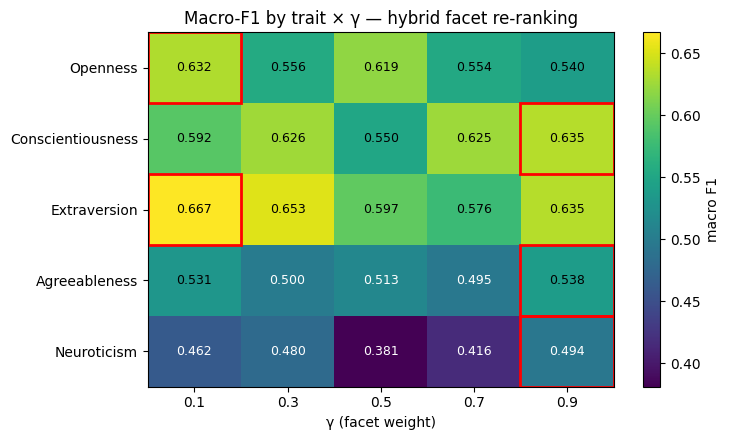

Saved: F:\std\GR\code\model_x_ocean\result\gamma_sweep\gamma_f1_heatmap.png


In [13]:
if not all_eval.empty:
    import matplotlib.patches as mpatches

    # trait (rows) x gamma (cols) macro-F1 matrix, in canonical trait order.
    # evaluate() writes SHORT trait names (e.g. "Openness"); order by TRAIT_SHORT
    # and append any leftover rows rather than dropping them.
    mat = all_eval.pivot_table(index="trait", columns="gamma", values="macro_f1")
    _order = [t for t in TRAIT_SHORT.values() if t in mat.index]
    _order += [t for t in mat.index if t not in _order]
    mat = mat.reindex(_order)

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    im = ax.imshow(mat.values, cmap="viridis", aspect="auto")

    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels([f"{g:g}" for g in mat.columns])
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)
    ax.set_xlabel("γ (facet weight)")
    ax.set_title("Macro-F1 by trait × γ — hybrid facet re-ranking")

    # annotate every cell; pick text colour for contrast against the colormap
    vmin, vmax = np.nanmin(mat.values), np.nanmax(mat.values)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]
            frac = (val - vmin) / (vmax - vmin) if vmax > vmin else 0.5
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    color="white" if frac < 0.5 else "black", fontsize=9)
        # box the best gamma for this trait (best cell in the row)
        j_best = int(np.nanargmax(mat.values[i]))
        ax.add_patch(mpatches.Rectangle((j_best - 0.5, i - 0.5), 1, 1,
                                        fill=False, edgecolor="red", lw=2))

    fig.colorbar(im, ax=ax, label="macro F1")
    plt.tight_layout()

    hm_path = sweep_root / "gamma_f1_heatmap.png"
    plt.savefig(hm_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {hm_path}")
else:
    print("No results yet — run Step 5 first.")